In [1]:
import jax
import jax.numpy as jnp

from crn_jax import models
from crn_jax.plotting import plot_species_distributions, plot_species_trajectories

E0514 16:58:58.290052   69349 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 23.52GiB (25251643392 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0514 16:58:58.290317   69349 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 21.17GiB (22726477824 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0514 16:58:58.290568   69349 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 19.05GiB (20453828608 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0514 16:58:58.290819   69349 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 17.14GiB (18408445952 bytes) of device memory: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
E0514 16:58:58.291061   69349 cuda_executor.cc:1206] [0] Failed to allocate device memory: INTERNAL: [0] Failed to allocate 15.43GiB (16567601152 by

## Setup

In [20]:
key = jax.random.PRNGKey(0)
N_REPLICATES = 1000

In [7]:
def run_and_plot_distribution(model, x0, n_steps=200, params=None, title=None):
    """Simulate one trajectory per row of ``x0`` and plot each species' empirical
    marginal distribution over time as a heatmap.

    ``x0`` is a ``(n_replicates, len(model.SPECIES))`` array of per-replicate initial
    counts. ``params`` defaults to ``model.Params.default()`` if not supplied — pass
    a different ``Params`` instance (e.g. ``Params.bistable()``) to override the regime.
    """
    if params is None:
        params = model.Params.default()
    print("Params:", params.__dict__)
    n_replicates = x0.shape[0]
    dataset = models.sample_trajectories(model, params=params, key=key, x0=x0, dt=0.1, n_steps=n_steps)

    if title is None:
        title = f"{model.__name__.rsplit('.', 1)[-1]} (N={n_replicates})"

    return plot_species_distributions(dataset, title=title)


def run_and_plot_trajectories(model, x0, n_steps=200, params=None, title=None, alpha=0.05):
    """Simulate one trajectory per row of ``x0`` and plot the per-species spaghetti.

    Same call interface as ``run_and_plot_distribution`` but renders each replicate
    as an overlaid step-line (grey, semi-transparent — no color coding, density
    emerges from overlap). Useful for bistable / multimodal cases where the
    marginal heatmap loses the joint structure across species.
    """
    if params is None:
        params = model.Params.default()
    print("Params:", params.__dict__)
    n_replicates = x0.shape[0]
    dataset = models.sample_trajectories(model, params=params, key=key, x0=x0, dt=0.1, n_steps=n_steps)

    if title is None:
        title = f"{model.__name__.rsplit('.', 1)[-1]} (N={n_replicates})"

    colors = ["grey"] * len(model.SPECIES)
    return plot_species_trajectories(dataset, title=title, colors=colors, alpha=alpha)

## Many-trajectory ensembles (N=1000)

Params: {'alpha': 5.0, 'delta': 1.0}


(<Figure size 700x180 with 2 Axes>,
 array([<Axes: xlabel='time', ylabel='X'>], dtype=object))

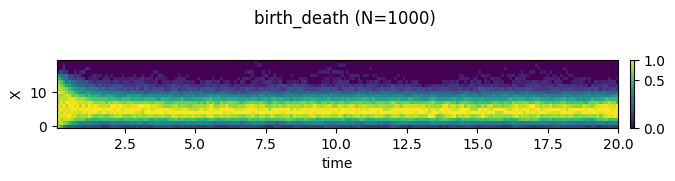

In [21]:
# Birth-death. A single species is produced at a constant rate and decays first-order;
# the stationary distribution is Poisson with mean α/δ = 5. Seeding x0 uniformly across
# {0..15} (wider than the stationary support) lets us watch every replicate relax back
# toward Poisson(5) over a few decay times (1/δ = 1).
# Species: X (the species count).
x0 = jax.random.randint(jax.random.PRNGKey(1), (N_REPLICATES, 1), minval=0, maxval=16)
run_and_plot_distribution(models.birth_death, x0=x0)

Params: {'k_R': 0.6, 'gamma_R': 0.3466, 'k_P': 6.931, 'gamma_P': 0.01155}


(<Figure size 700x360 with 4 Axes>,
 array([<Axes: ylabel='R'>, <Axes: xlabel='time', ylabel='P'>],
       dtype=object))

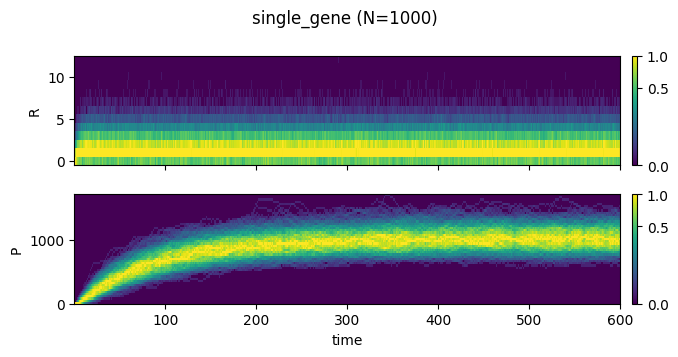

In [ ]:
# Single-gene expression. Transcription produces mRNA constitutively, which is then
# translated into protein; both species decay first-order. The simplest model with a
# hidden delay between input and output.
# Species: R (mRNA), P (protein).

# Start from nothing and watch mRNA slowly increase P until steady-state
x0 = jnp.zeros((N_REPLICATES, 2))
run_and_plot_distribution(models.single_gene, x0=x0, n_steps=6000);

Params: {'beta_0': 0.0, 'beta_1': 0.05776, 'K': 1.0, 'n': 1.0, 'delta': 0.01155}


(<Figure size 700x180 with 2 Axes>,
 array([<Axes: xlabel='time', ylabel='X'>], dtype=object))

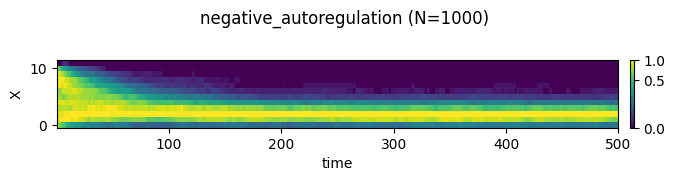

In [ ]:
# Negative autoregulation. A single species represses its own production through a Hill
# term — a classic noise-reducing motif that speeds up response and tightens the
# stationary distribution compared to unregulated expression.
# Species: X (the species count).
# Seed x0 ~ Uniform{0..10} (much wider than the SS spread) to see self-repression squeeze
# the trajectories down to their tight stationary distribution around ⟨X⟩ ≈ 1.79.
# n_steps=5000 → ~500 min, ~6× the 1/δ ≈ 87 min decay time, enough to relax.
x0 = jax.random.randint(jax.random.PRNGKey(4), (N_REPLICATES, 1), minval=0, maxval=11)
run_and_plot_distribution(models.negative_autoregulation, x0=x0, n_steps=5000);

Params: {'beta_0': 0.005776, 'beta_1': 0.05776, 'K': 1.0, 'n': 1.0, 'delta': 0.01155}


(<Figure size 700x180 with 2 Axes>,
 array([<Axes: xlabel='time', ylabel='X'>], dtype=object))

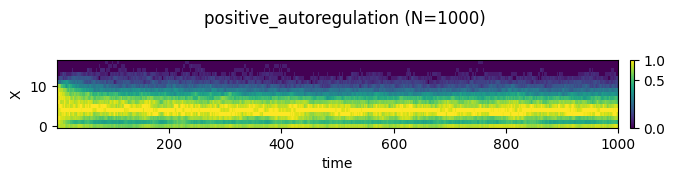

In [ ]:
# Positive autoregulation. A single species activates its own production through a Hill
# term. With sub-cooperative Hill (n ≤ 1) the equilibrium is monostable and graded; with
# sharper cooperativity and lower leakage the dynamics become switch-like — see the
# next cell for the bistable regime of this same circuit.
# Species: X (the species count).
# Seed x0 ~ Uniform{0..10} (much wider than the SS spread)
x0 = jax.random.randint(jax.random.PRNGKey(5), (N_REPLICATES, 1), minval=0, maxval=11)
run_and_plot_distribution(models.positive_autoregulation, x0=x0, n_steps=10000);

Params: {'beta_0': 0.0, 'beta_1': 0.5776, 'K': 20.0, 'n': 4.0, 'delta': 0.01155}


(<Figure size 700x180 with 2 Axes>,
 array([<Axes: xlabel='time', ylabel='X'>], dtype=object))

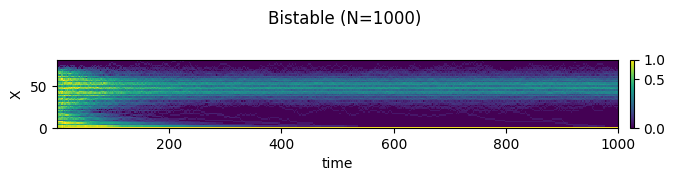

In [ ]:
# Bistable self-activation — same reactions as positive_autoregulation, run in the
# bistable regime via Params.bistable() (BE150 dimensionless ratios β/(γK) = 2.5,
# n = 4, scaled to copy numbers high enough for stochastic persistence).
# Three deterministic fixed points: X=0 (stable, absorbing), X_saddle ≈ 17, X_high ≈ 49.
# Species: X (the species count).
# Spread x0 ~ Uniform{0..70} so some replicates start below the saddle (commit to
# X=0 and stay there) and others above (commit to high). Trajectory spaghetti shows
# the bimodal commitment directly.
x0 = jax.random.randint(jax.random.PRNGKey(6), (N_REPLICATES, 1), minval=0, maxval=70)
run_and_plot_distribution(
    models.positive_autoregulation,
    x0=x0,
    n_steps=10000,
    params=models.positive_autoregulation.Params.bistable(),
    title=f"Bistable (N={N_REPLICATES})",
);

Params: {'alpha_A': 0.05776, 'delta_A': 0.01155, 'beta_B0': 0.0005776, 'beta_B1': 0.05776, 'K_A': 5.0, 'n_A': 1.0, 'delta_B': 0.01155}


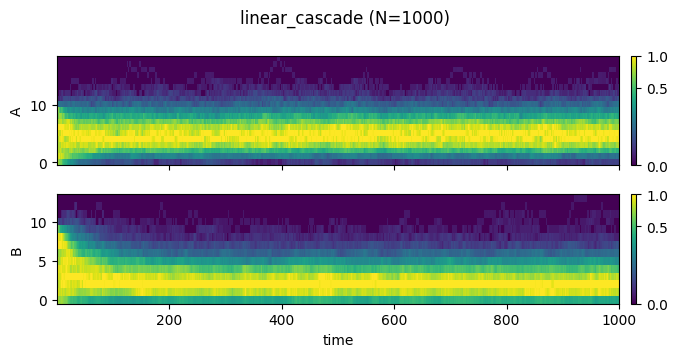

In [27]:
# Linear activation cascade. A is produced at a constant rate and decays first-order.
# A then activates B through a Hill term. The simplest open signalling cascade.
# Species: A (upstream driver), B (downstream target).
# Seed both species ~ Uniform{0..10} (wider than the SS spread of ⟨A⟩=5, ⟨B⟩≈2.55).
x0 = jax.random.randint(jax.random.PRNGKey(7), (N_REPLICATES, 2), minval=0, maxval=10)
run_and_plot_distribution(models.linear_cascade, x0=x0, n_steps=10000);

Params: {'beta_A0': 0.2246, 'beta_A1': 58.23, 'beta_B0': 1.005, 'beta_B1': 17.39, 'K_A': 31.94, 'K_B': 30.0, 'n_A': 2.0, 'n_B': 2.0, 'delta_A': 0.0165, 'delta_B': 0.0165}


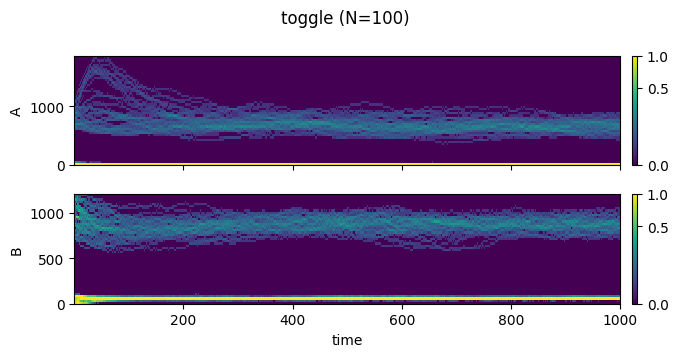

In [ ]:
# Toggle switch (Lugagne et al. 2017 E. coli LacI/TetR fit, adiabatically reduced).
# Two species mutually repress each other; the system is bistable, with LacI-wins
# (A high, B low) and TetR-wins (A low, B high) as stable basins.
# Species: A = LacI, B = TetR. Units: a.u. (fluorescence).
# Three deterministic fixed points: LacI-wins (A≈660, B≈63); TetR-wins (A≈18, B≈864);
# saddle at (A≈73, B≈228).
#
# Use N=100 (50 seeded inside each basin) to view trajectories in both basins
k_LacI, k_TetR = jax.random.split(jax.random.PRNGKey(8))
N_HALF = 50
x0_LacI = jax.random.randint(k_LacI, (N_HALF, 2), minval=jnp.array([600, 0]), maxval=jnp.array([1000, 100]))
x0_TetR = jax.random.randint(k_TetR, (N_HALF, 2), minval=jnp.array([0, 700]), maxval=jnp.array([50, 1200]))
x0 = jnp.concatenate([x0_LacI, x0_TetR], axis=0)
run_and_plot_distribution(models.toggle, x0=x0, n_steps=10000);

In [ ]:
# Activator-repressor pair. Mixed-sign two-node feedback: A activates B and B represses A.
# For suitable parameters this circuit can produce sustained oscillations (a relaxation
# oscillator) — the simplest two-node motif that ticks.
# Species: A (activator), B (repressor).
# Note: with N=1000 replicates at random phase, the trajectory spaghetti smears out
# the oscillation; the per-trajectory cycle isn't directly visible here.
x0 = jax.random.randint(jax.random.PRNGKey(9), (N_REPLICATES, 2), minval=0, maxval=11)
run_and_plot_trajectories(models.activator_repressor, x0=x0)

In [ ]:
# Mutual activation. Two species activate each other through Hill terms. This positive
# two-node feedback can amplify small fluctuations into bistability under sharp Hill
# cooperativity.
# Species: A, B (mutually activating genes).
x0 = jax.random.randint(jax.random.PRNGKey(10), (N_REPLICATES, 2), minval=0, maxval=11)
run_and_plot_trajectories(models.mutual_activation, x0=x0)

In [ ]:
# Coherent feed-forward loop (AND logic). X drives Y, and X and Y together gate Z; X is
# not produced by the model (it enters as an initial condition and decays). The
# AND-gate at Z introduces a sign-sensitive delay: Z only responds to sustained X pulses.
# Species: X (input pulse), Y (intermediate), Z (output).
# Sample X ~ Uniform{0..10} so some replicates start above the threshold Ty=0.5 (driving
# Y/Z briefly before X decays below threshold) and others below (silent). Y and Z = 0.
X0 = jax.random.randint(jax.random.PRNGKey(11), (N_REPLICATES, 1), minval=0, maxval=11)
YZ0 = jnp.zeros((N_REPLICATES, 2), dtype=jnp.int32)
x0 = jnp.concatenate([X0, YZ0], axis=-1)
run_and_plot_trajectories(models.coherent_ffl, x0=x0)

In [ ]:
# Incoherent feed-forward loop. A activates both B and C, while B represses C. The opposing
# direct (A→C) and indirect (A→B⊣C) paths produce a pulse / adaptive response on C: C
# transiently rises after A turns on, then falls as the slower repression through B kicks in.
# Species: A (input), B (intermediate repressor), C (output).
x0 = jax.random.randint(jax.random.PRNGKey(12), (N_REPLICATES, 3), minval=0, maxval=11)
run_and_plot_trajectories(models.incoherent_ffl, x0=x0)

In [ ]:
# Repressilator (Elowitz-Leibler, 2000). A three-node repressive ring in which A
# represses B, B represses C, and C represses A. With sufficient Hill cooperativity and a
# clear timescale separation the system enters a stable limit cycle — a synthetic oscillator.
# Species: A, B, C (the three mutually-repressing genes).
# Sample each species ~ Uniform{0..100} (around the unrepressed SS ~ β₁/δ ≈ 86). With
# random ICs across N=1000 replicates, individual trajectories cycle but the spaghetti
# smears out the oscillation; the per-trajectory cycle isn't directly visible here.
x0 = jax.random.randint(jax.random.PRNGKey(13), (N_REPLICATES, 3), minval=0, maxval=101)
run_and_plot_trajectories(models.repressilator, x0=x0)

In [ ]:
# Cyclic hybrid ring. A mixed-sign three-node loop in which C represses A, A activates B,
# and B represses C. The two repressors and one activator give qualitatively different
# dynamics from the pure-repressive repressilator.
# Species: A, B, C (the three species in the ring).
x0 = jax.random.randint(jax.random.PRNGKey(14), (N_REPLICATES, 3), minval=0, maxval=11)
run_and_plot_trajectories(models.cyclic_ring, x0=x0)